In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

2026-06-14 07:56:14.426821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781423774.664721      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781423774.727413      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781423775.252795      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781423775.252837      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781423775.252841      16 computation_placer.cc:177] computation placer alr

In [2]:
print(os.listdir("/kaggle/input/datasets"))

['awsaf49']


In [3]:
train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
test_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

# Loading Images

In [4]:
x_train = []

for digit in range(10):
    folder = os.path.join(train_path, str(digit))

    files = os.listdir(folder)[:500]

    for img_name in files:
        img = cv2.imread(
            os.path.join(folder, img_name),
            cv2.IMREAD_GRAYSCALE
        )

        img = img / 255.0
        x_train.append(img)

x_train = np.array(x_train)
x_train = np.reshape(x_train, (-1, 28, 28, 1))

print("Training Shape:", x_train.shape)

Training Shape: (5000, 28, 28, 1)


# Adding Noise

In [5]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)

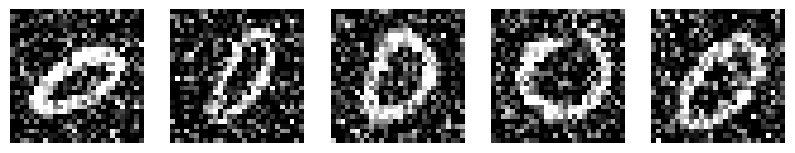

In [6]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# Building Autoencoder

In [7]:
input_img = Input(shape=(28,28,1))

x = Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(8, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

2026-06-14 07:57:08.577320: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [8]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.5492 - val_loss: 0.4584
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.4002 - val_loss: 0.2931
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.2462 - val_loss: 0.2010
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.1849 - val_loss: 0.1774
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.1652 - val_loss: 0.1608


# Denoising Images

In [9]:
decoded_imgs = autoencoder.predict(x_train_noisy[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


# Final Result

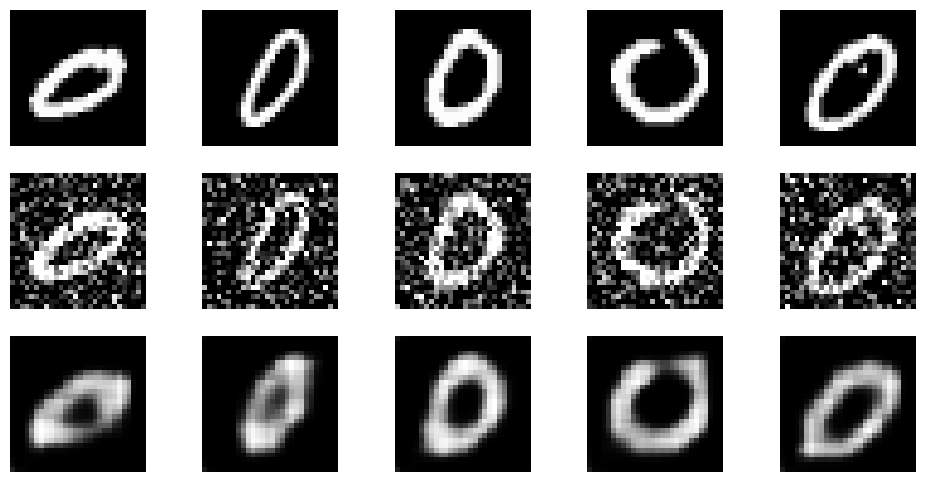

In [10]:
plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# 

# Observations

1. The MNIST images were successfully loaded and normalized.
2. Artificial noise was added to create noisy images.
3. The Autoencoder learned compressed image representations using encoder and decoder layers.
4. The reconstructed images contained significantly less noise than the noisy inputs.
6. The model successfully demonstrated the image denoising capability of Autoencoders.